In [1]:
# PROYECTO 2: Análisis de Retención de Clientes (E-commerce)
# Herramientas: MySQL, Python, Pandas, Matplotlib, Seaborn

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

conexion = mysql.connector.connect(
    host="localhost",
    user="root",
    password="", 
    database="ecommerce_analytics"
)

print("¡Conexión establecida con éxito! 🎉")

¡Conexión establecida con éxito! 🎉


In [3]:
# Traemos la tabla de usuarios
query_usuarios = "SELECT * FROM usuarios;"
df_usuarios = pd.read_sql(query_usuarios, conexion)

# Traemos la tabla de pedidos
query_pedidos = "SELECT * FROM pedidos;"
df_pedidos = pd.read_sql(query_pedidos, conexion)
conexion.close()

print("=== DATOS CARGADOS ===")
print(f"Usuarios cargados: {df_usuarios.shape[0]}")
print(f"Pedidos cargados: {df_pedidos.shape[0]}")

=== DATOS CARGADOS ===
Usuarios cargados: 5
Pedidos cargados: 10


In [4]:
print("--- MUESTRA DE USUARIOS ---")
print(df_usuarios.head(2))

print("\n--- MUESTRA DE PEDIDOS ---")
print(df_pedidos.head(2))

--- MUESTRA DE USUARIOS ---
   usuario_id          nombre      pais fecha_registro
0           1  Carlos Mendoza    España     2025-01-10
1           2       Ana Silva  Portugal     2025-01-15

--- MUESTRA DE PEDIDOS ---
   pedido_id  usuario_id fecha_compra  total_venta    categoria
0        101           1   2025-01-12        450.0  Smartphones
1        102           2   2025-01-16       1200.0      Laptops


In [5]:
df_completo = pd.merge(df_pedidos, df_usuarios, on='usuario_id', how='inner')

print("=== NUEVA TABLA FUSIONADA (df_completo) ===")
print(f"Total de filas tras la unión: {df_completo.shape[0]}")
print("\nColumnas actuales en la tabla combinada:")
print(df_completo.columns.tolist())

=== NUEVA TABLA FUSIONADA (df_completo) ===
Total de filas tras la unión: 10

Columnas actuales en la tabla combinada:
['pedido_id', 'usuario_id', 'fecha_compra', 'total_venta', 'categoria', 'nombre', 'pais', 'fecha_registro']


In [6]:
df_completo.head(3)

,pedido_id,usuario_id,fecha_compra,total_venta,categoria,nombre,pais,fecha_registro
0,101,1,2025-01-12,450.0,Smartphones,Carlos Mendoza,España,2025-01-10
1,102,2,2025-01-16,1200.0,Laptops,Ana Silva,Portugal,2025-01-15
2,103,1,2025-02-20,45.0,Accesorios,Carlos Mendoza,España,2025-01-10


In [7]:
pedidos_por_cliente = df_completo.groupby('nombre')['pedido_id'].count().reset_index()

pedidos_por_cliente.columns = ['Nombre del Cliente', 'Total de Pedidos']

pedidos_por_cliente = pedidos_por_cliente.sort_values(by='Total de Pedidos', ascending=False)

print("=== FRECUENCIA DE COMPRA POR CLIENTE ===")
print(pedidos_por_cliente)

=== FRECUENCIA DE COMPRA POR CLIENTE ===
  Nombre del Cliente  Total de Pedidos
1     Carlos Mendoza                 3
0          Ana Silva                 2
2        Jean Dupont                 2
3     Laura Martínez                 2
4        Lucas Rossi                 1


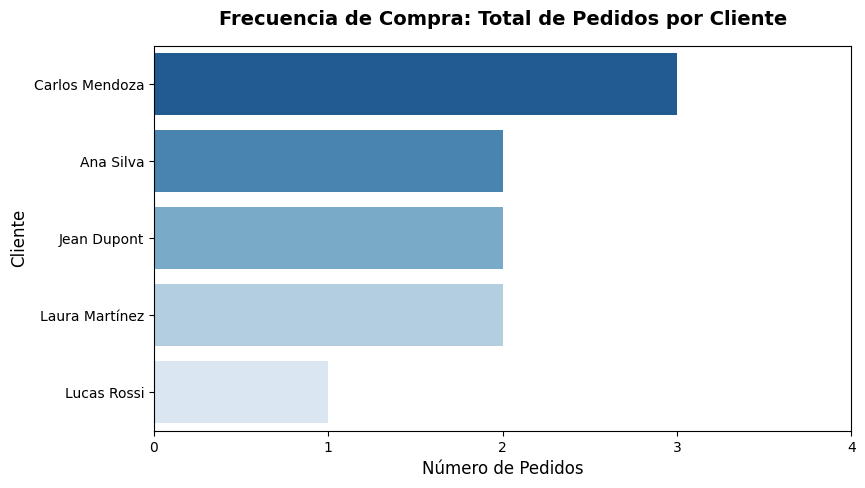

In [8]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x='Total de Pedidos', 
    y='Nombre del Cliente', 
    data=pedidos_por_cliente, 
    palette='Blues_r',
    hue='Nombre del Cliente',  
    legend=False               
)

plt.title('Frecuencia de Compra: Total de Pedidos por Cliente', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Pedidos', fontsize=12)
plt.ylabel('Cliente', fontsize=12)

plt.xticks([0, 1, 2, 3, 4])

plt.show()

In [9]:
ticket_medio_cliente = df_completo.groupby('nombre')['total_venta'].mean().reset_index()

ticket_medio_cliente.columns = ['Nombre del Cliente', 'Ticket Medio ($)']

ticket_medio_cliente = ticket_medio_cliente.sort_values(by='Ticket Medio ($)', ascending=False)

print("=== TICKET MEDIO POR CLIENTE ===")
print(ticket_medio_cliente)

=== TICKET MEDIO POR CLIENTE ===
  Nombre del Cliente  Ticket Medio ($)
4        Lucas Rossi             950.0
0          Ana Silva             640.0
2        Jean Dupont             455.0
3     Laura Martínez             325.0
1     Carlos Mendoza             265.0


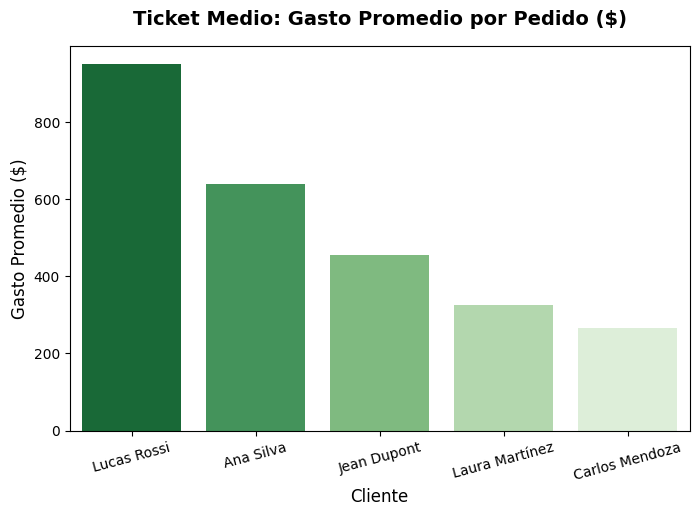

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Nombre del Cliente', 
    y='Ticket Medio ($)', 
    data=ticket_medio_cliente, 
    palette='Greens_r',
    hue='Nombre del Cliente',
    legend=False
)

plt.title('Ticket Medio: Gasto Promedio por Pedido ($)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cliente', fontsize=12)
plt.ylabel('Gasto Promedio ($)', fontsize=12)

plt.xticks(rotation=15)

plt.show()

In [11]:
ventas_categoria = df_completo.groupby('categoria')['total_venta'].sum().reset_index()

ventas_categoria = ventas_categoria.sort_values(by='total_venta', ascending=False)

print("=== VENTAS TOTALES POR CATEGORÍA ===")
print(ventas_categoria)

=== VENTAS TOTALES POR CATEGORÍA ===
     categoria  total_venta
2      Laptops       2050.0
3  Smartphones       1900.0
1        Audio        450.0
0   Accesorios        185.0


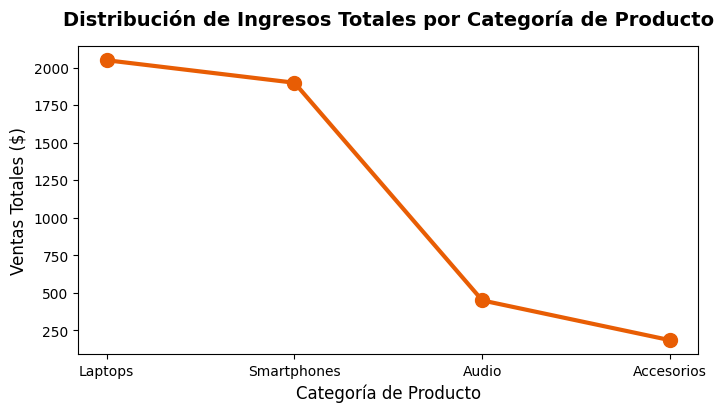

In [12]:
plt.figure(figsize=(8, 4))

plt.plot(
    ventas_categoria['categoria'], 
    ventas_categoria['total_venta'], 
    color='#E85D04',      
    linewidth=3,         
    marker='o',           
    markersize=10         
)

plt.title('Distribución de Ingresos Totales por Categoría de Producto', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Categoría de Producto', fontsize=12)
plt.ylabel('Ventas Totales ($)', fontsize=12)

plt.show()

In [13]:
print("""=== CONCLUSIONES E INSIGHTS DE NEGOCIO ===

1. COMPORTAMIENTO Y FIDELIZACIÓN (RETENCIÓN)
   El 80% de los clientes registrados (4 de 5) han realizado más de una 
   compra en la plataforma. Carlos Mendoza es el cliente más frecuente 
   con un total de 3 pedidos. La tasa de retención inicial es excelente.

2. ANÁLISIS DEL TICKET MEDIO vs. FRECUENCIA
   Se detecta una relación inversa interesante: Carlos Mendoza compra muchas 
   veces pero con un ticket medio bajo ($265.00). En contraste, Lucas Rossi 
   tiene la menor frecuencia (1 solo pedido) pero el ticket medio más alto 
   del negocio ($950.00).
   *Estrategia:* Se recomienda lanzar campañas de up-selling a Carlos para 
   subir su ticket, y de remarketing a Lucas para aumentar su frecuencia.

3. CATEGORÍAS CORE DE INGRESO
   Las categorías 'Laptops' y 'Smartphones' sostienen el peso financiero 
   del e-commerce. Los productos de 'Audio' y 'Accesorios' actúan como 
   complementos de bajo valor absoluto.

4. FLUJO DE TRABAJO TÉCNICO (DATA PIPELINE)
   El proyecto demuestra la capacidad de diseñar un flujo de datos completo: 
   desde el almacenamiento relacional en producción (MySQL), la extracción 
   segura mediante Python, y la manipulación avanzada con Pandas y Seaborn.""")

=== CONCLUSIONES E INSIGHTS DE NEGOCIO ===

1. COMPORTAMIENTO Y FIDELIZACIÓN (RETENCIÓN)
   El 80% de los clientes registrados (4 de 5) han realizado más de una 
   compra en la plataforma. Carlos Mendoza es el cliente más frecuente 
   con un total de 3 pedidos. La tasa de retención inicial es excelente.

2. ANÁLISIS DEL TICKET MEDIO vs. FRECUENCIA
   Se detecta una relación inversa interesante: Carlos Mendoza compra muchas 
   veces pero con un ticket medio bajo ($265.00). En contraste, Lucas Rossi 
   tiene la menor frecuencia (1 solo pedido) pero el ticket medio más alto 
   del negocio ($950.00).
   *Estrategia:* Se recomienda lanzar campañas de up-selling a Carlos para 
   subir su ticket, y de remarketing a Lucas para aumentar su frecuencia.

3. CATEGORÍAS CORE DE INGRESO
   Las categorías 'Laptops' y 'Smartphones' sostienen el peso financiero 
   del e-commerce. Los productos de 'Audio' y 'Accesorios' actúan como 
   complementos de bajo valor absoluto.

4. FLUJO DE TRABAJO TÉC